<a href="https://colab.research.google.com/github/lizbrandao/PUCRJ/blob/main/MVP_Spotify_Livia_Brandao_corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lívia Brandão  
**Matrícula:** 4052025002389  
**Dataset:** Most Streamed Spotify Songs 2023

## Descrição do Problema

O consumo de música por streaming transformou a indústria fonográfica, tornando plataformas como o Spotify fontes valiosas para análise de comportamento do público e desempenho de conteúdos. Nesse cenário, compreender os fatores associados ao sucesso de uma música pode gerar insights relevantes para artistas, gravadoras, plataformas digitais e estratégias de marketing.

Este trabalho tem como objetivo analisar o dataset **Most Streamed Spotify Songs 2023**, buscando identificar padrões relacionados ao desempenho das músicas, medido principalmente pelo número de streams. A proposta envolve análise exploratória dos dados, tratamento de inconsistências e aplicação de técnicas de pré-processamento, com foco em compreender quais variáveis parecem estar mais associadas ao sucesso das faixas.

## Hipóteses do Problema

As hipóteses definidas para este trabalho são:

1. Músicas com maior presença em playlists e charts tendem a apresentar maior número de streams.
2. Características musicais, como danceability, energy e valence, apresentam alguma relação com o sucesso das músicas.
3. O número de streams é concentrado em poucas músicas e poucos artistas, indicando uma distribuição desigual de sucesso.
4. O ano de lançamento pode influenciar o desempenho das músicas em streams.

## Tipo de Problema

Este trabalho é centrado em **análise exploratória e pré-processamento de dados**. Embora o dataset possa ser utilizado futuramente em tarefas de regressão ou classificação, o foco deste MVP é entender a estrutura dos dados, investigar padrões, realizar transformações e responder às hipóteses propostas.

## Seleção de Dados

O dataset utilizado foi o **Most Streamed Spotify Songs 2023**, obtido em repositório público. A escolha se justifica por se tratar de uma base real, atual e aderente ao objetivo de investigar fatores associados ao sucesso de músicas em plataformas digitais.

Além disso, o dataset possui variáveis numéricas e categóricas, permitindo explorar estatísticas descritivas, relações entre atributos, presença de valores ausentes e aplicação de técnicas de pré-processamento.

## Atributos do Dataset

O dataset reúne informações sobre músicas em destaque no Spotify em 2023, incluindo variáveis como:

- `track_name`: nome da música
- `artist(s)_name`: nome do artista ou artistas
- `artist_count`: quantidade de artistas na faixa
- `released_year`, `released_month`, `released_day`: data de lançamento
- `streams`: número total de reproduções
- `in_spotify_playlists`: quantidade de playlists do Spotify em que a música aparece
- `in_spotify_charts`: quantidade de aparições em charts do Spotify
- `bpm`: batidas por minuto
- `danceability_%`: potencial de dança
- `valence_%`: positividade emocional da música
- `energy_%`: intensidade/energia da faixa
- `acousticness_%`: nível de acústica
- `instrumentalness_%`: presença instrumental
- `liveness_%`: traços de performance ao vivo
- `speechiness_%`: presença de fala

In [1]:
# Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
# Configurações visuais

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Carga dos Dados

O notebook tenta primeiro ler o arquivo local `spotify-2023.csv`, ideal para uso direto no Google Colab após upload do CSV.  
Se preferir, basta substituir pela leitura do arquivo via URL raw do GitHub.

In [3]:
# Carga do dataset

from google.colab import files

uploaded = files.upload()
nome_arquivo = list(uploaded.keys())[0]

df = pd.read_csv(nome_arquivo, encoding='latin1')
df.head()


Saving spotify-2023.csv to spotify-2023.csv


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Análise Exploratória dos Dados

A análise exploratória tem como objetivo compreender a estrutura do dataset, os tipos de variáveis presentes, a qualidade dos dados e os principais padrões relacionados ao desempenho das músicas.

In [4]:
# Dimensão do dataset
print(f'Total de linhas: {df.shape[0]}')
print(f'Total de colunas: {df.shape[1]}')

Total de linhas: 953
Total de colunas: 24


In [5]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

A inspeção inicial permite identificar a estrutura da base, os tipos de dados e possíveis colunas que exigem tratamento. Essa etapa é essencial para orientar decisões de limpeza, transformação e análise.

In [6]:
# Conversão de colunas para numérico quando necessário
colunas_para_converter = ['streams', 'in_deezer_playlists', 'in_shazam_charts']

for col in colunas_para_converter:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
track_name,object
artist(s)_name,object
artist_count,int64
released_year,int64
released_month,int64
released_day,int64
in_spotify_playlists,int64
in_spotify_charts,int64
streams,float64
in_apple_playlists,int64


In [7]:
# Verificação de valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
key,95
in_deezer_playlists,79
in_shazam_charts,57
streams,1
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
in_spotify_charts,0
in_spotify_playlists,0


A análise de valores ausentes é importante para avaliar a consistência da base. Após a conversão de tipos, alguns valores podem se tornar nulos, o que exige tratamento para evitar distorções nas análises seguintes.

In [8]:
# Estatísticas descritivas
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,9.520000e+02,953.000000,953.000000,874.000000,953.000000,896.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,5.141374e+08,67.812172,51.908709,109.740275,2.666317,51.176339,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,5.668569e+08,86.441493,50.630241,178.811406,6.035599,126.487856,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,1.416362e+08,13.000000,7.000000,12.000000,0.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,2.905309e+08,34.000000,38.000000,36.500000,0.000000,2.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,6.738690e+08,88.000000,87.000000,110.000000,2.000000,36.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,974.000000,58.000000,953.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


As estatísticas descritivas oferecem uma visão geral das variáveis numéricas, incluindo tendência central, dispersão e extremos. Essa etapa é particularmente importante para identificar assimetrias e possíveis outliers.

## Distribuição de Streams

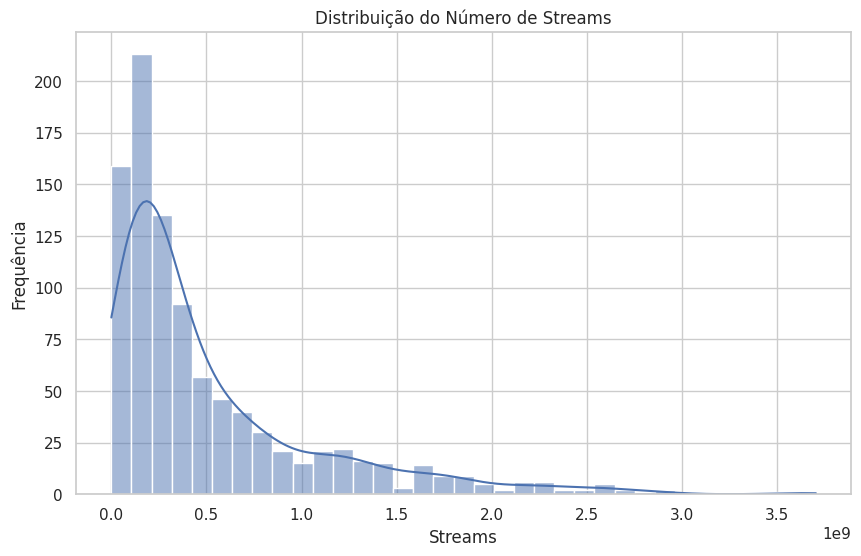

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['streams'], kde=True)
plt.title('Distribuição do Número de Streams')
plt.xlabel('Streams')
plt.ylabel('Frequência')
plt.show()

A distribuição do número de streams apresenta forte assimetria à direita, indicando que poucas músicas concentram um volume muito elevado de reproduções, enquanto a maior parte das faixas possui desempenho relativamente inferior. Esse comportamento é típico de mercados digitais, nos quais poucos conteúdos se tornam grandes sucessos.

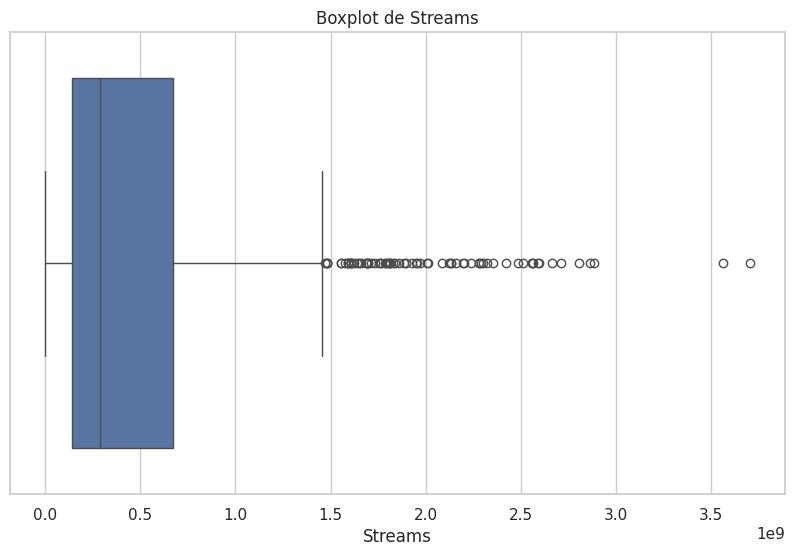

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['streams'])
plt.title('Boxplot de Streams')
plt.xlabel('Streams')
plt.show()

O boxplot reforça a presença de valores extremos, o que sugere forte concentração de sucesso em algumas poucas músicas. Esses valores não devem ser tratados automaticamente como erro, pois representam justamente uma característica relevante do fenômeno estudado.

## Top 10 músicas por número de streams

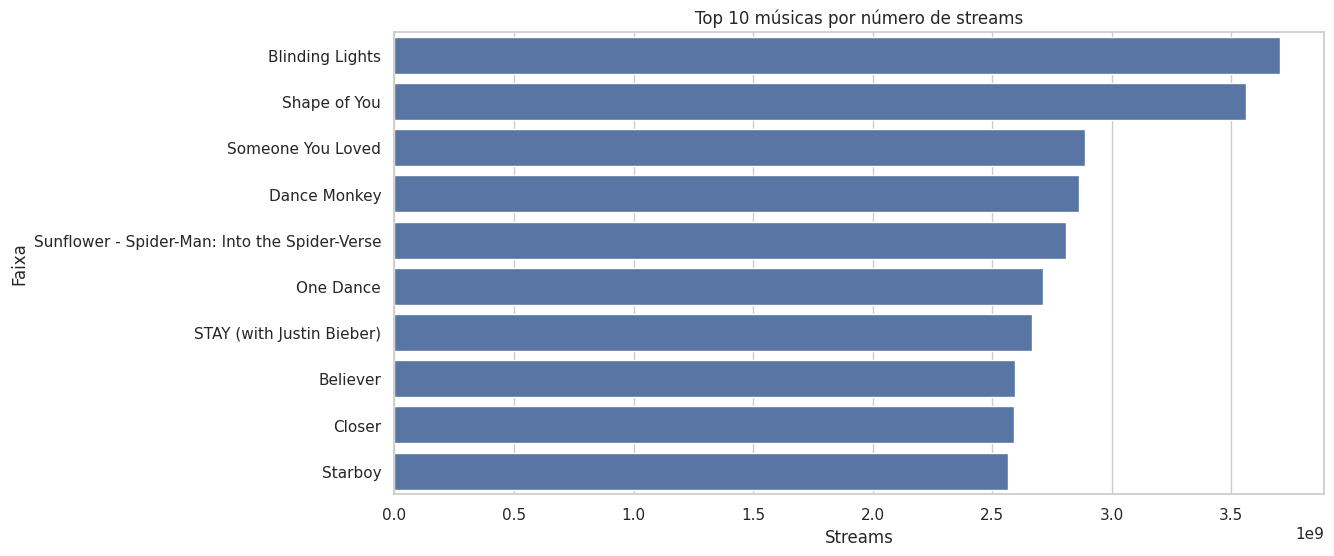

,track_name,artist(s)_name,streams
55,Blinding Lights,The Weeknd,3.703895e+09
179,Shape of You,Ed Sheeran,3.562544e+09
86,Someone You Loved,Lewis Capaldi,2.887242e+09
620,Dance Monkey,Tones and I,2.864792e+09
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.808097e+09
162,One Dance,"Drake, WizKid, Kyla",2.713922e+09
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.665344e+09
140,Believer,Imagine Dragons,2.594040e+09
725,Closer,"The Chainsmokers, Halsey",2.591224e+09
48,Starboy,"The Weeknd, Daft Punk",2.565530e+09


In [11]:
top10_musicas = df.sort_values('streams', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_musicas, x='streams', y='track_name')
plt.title('Top 10 músicas por número de streams')
plt.xlabel('Streams')
plt.ylabel('Faixa')
plt.show()

top10_musicas[['track_name', 'artist(s)_name', 'streams']]

O ranking das músicas mais reproduzidas evidencia a concentração de audiência em poucos títulos. Essa análise fortalece a hipótese de que o consumo musical no streaming tende a privilegiar grandes hits, em vez de se distribuir de forma uniforme entre as faixas.

## Top 10 artistas com maior frequência no dataset

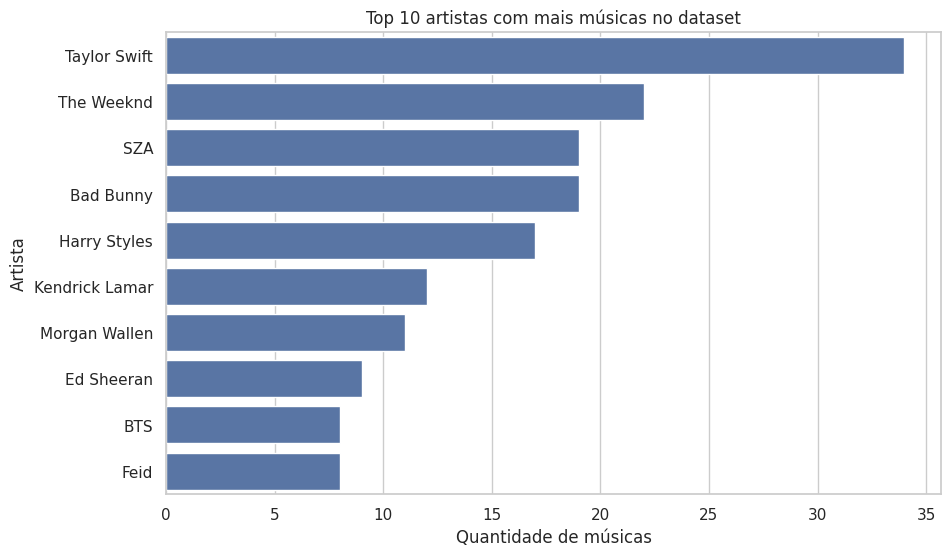

,count
artist(s)_name,
Taylor Swift,34
The Weeknd,22
SZA,19
Bad Bunny,19
Harry Styles,17
Kendrick Lamar,12
Morgan Wallen,11
Ed Sheeran,9
BTS,8


In [12]:
top_artistas = df['artist(s)_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_artistas.values, y=top_artistas.index)
plt.title('Top 10 artistas com mais músicas no dataset')
plt.xlabel('Quantidade de músicas')
plt.ylabel('Artista')
plt.show()

top_artistas

A frequência de aparição dos artistas no dataset sugere que alguns nomes possuem presença recorrente entre as músicas de destaque. Isso pode indicar maior capacidade de manter relevância de mercado, recorrência em playlists e forte apelo comercial.

## Distribuição por ano de lançamento

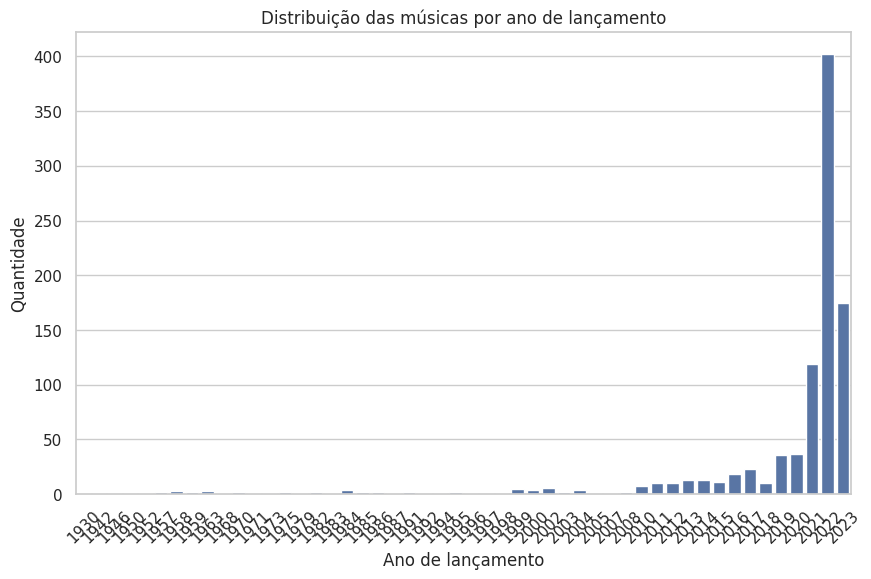

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='released_year', order=sorted(df['released_year'].dropna().unique()))
plt.title('Distribuição das músicas por ano de lançamento')
plt.xlabel('Ano de lançamento')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

A distribuição por ano de lançamento permite observar se o dataset é composto majoritariamente por músicas recentes ou se também inclui faixas mais antigas com relevância contínua. Essa análise ajuda a contextualizar o efeito de recência no desempenho das músicas.

## Streams e presença em playlists

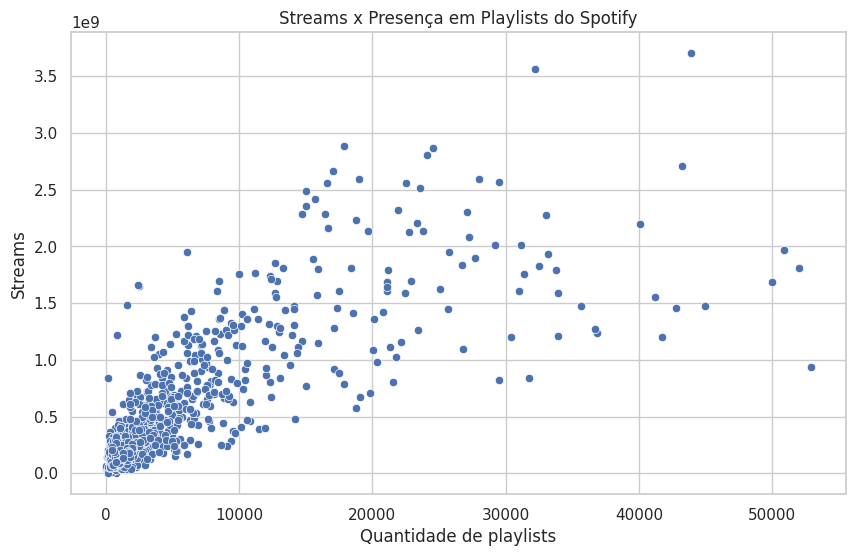

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='in_spotify_playlists', y='streams')
plt.title('Streams x Presença em Playlists do Spotify')
plt.xlabel('Quantidade de playlists')
plt.ylabel('Streams')
plt.show()

O gráfico sugere uma relação positiva entre presença em playlists e número de streams. Embora a análise exploratória não permita afirmar causalidade, os dados indicam que músicas com maior inserção em playlists tendem a alcançar maior volume de reproduções.

## Streams e presença em charts

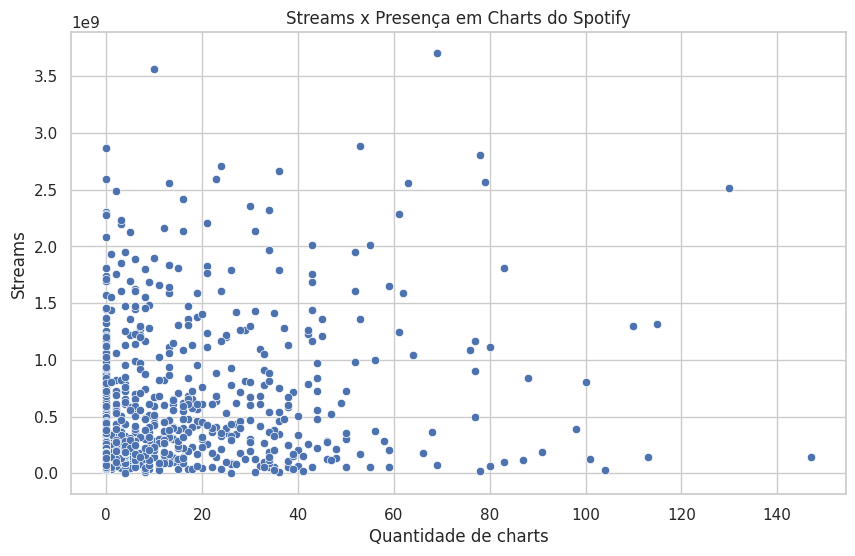

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='in_spotify_charts', y='streams')
plt.title('Streams x Presença em Charts do Spotify')
plt.xlabel('Quantidade de charts')
plt.ylabel('Streams')
plt.show()

A presença em charts também parece associada ao número de streams, ainda que com dispersão considerável. Isso é coerente com a lógica de mercado: músicas em evidência tendem a receber mais atenção e, consequentemente, mais reproduções.

## Correlação entre variáveis numéricas

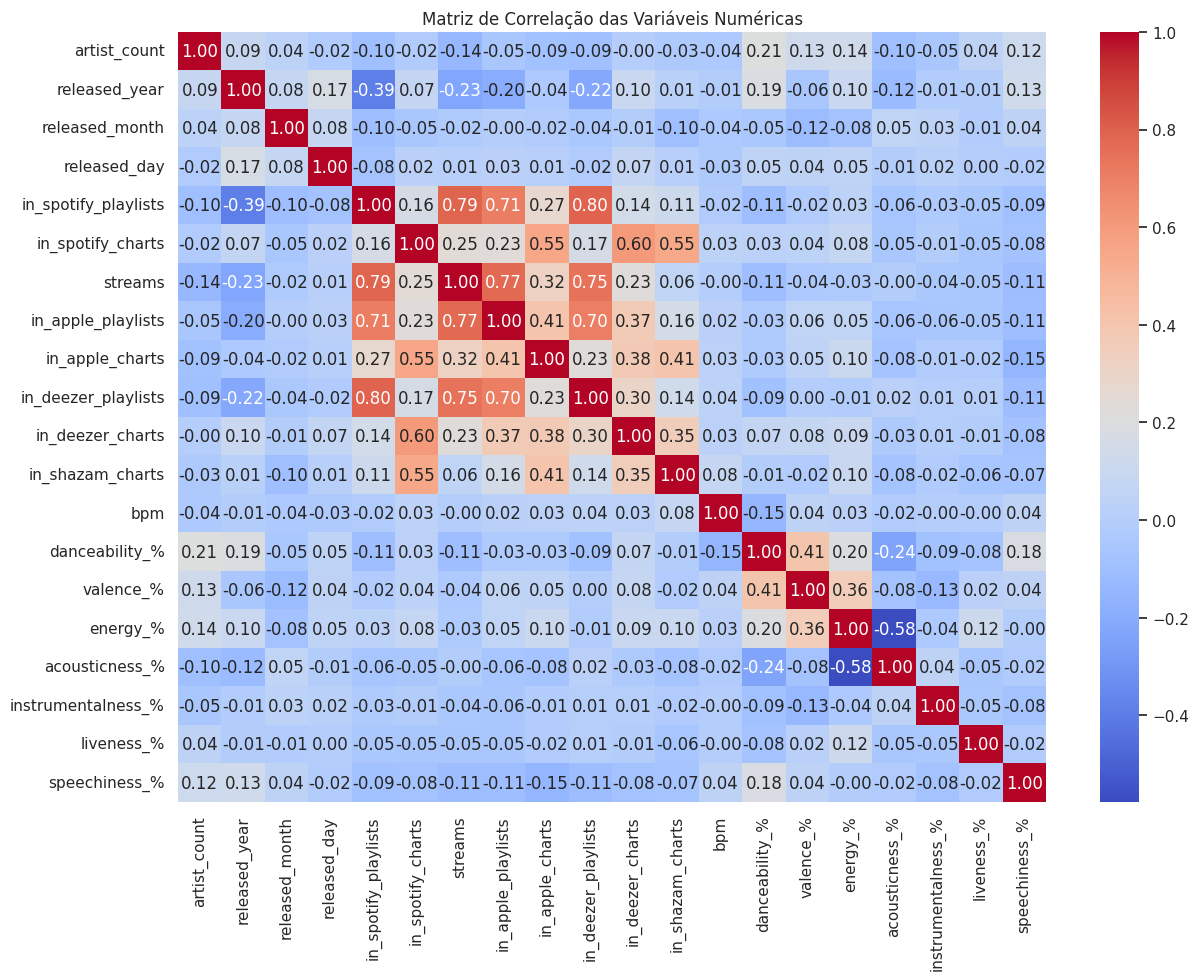

In [16]:
df_numerico = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

A matriz de correlação permite identificar associações lineares entre as variáveis numéricas. Em especial, interessa observar como `streams` se relaciona com presença em playlists, charts e atributos musicais. De forma geral, as variáveis de visibilidade tendem a apresentar relação mais forte com streams do que as características sonoras.

## Características musicais e sucesso

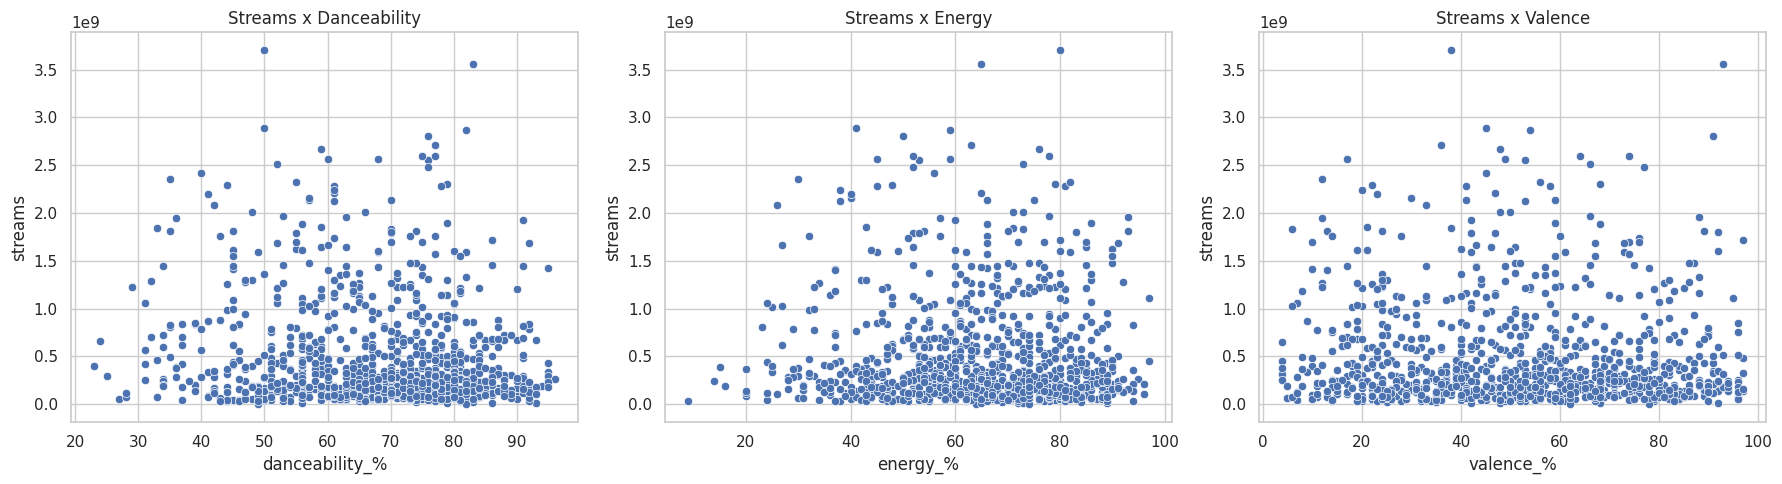

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=df, x='danceability_%', y='streams', ax=axes[0])
axes[0].set_title('Streams x Danceability')

sns.scatterplot(data=df, x='energy_%', y='streams', ax=axes[1])
axes[1].set_title('Streams x Energy')

sns.scatterplot(data=df, x='valence_%', y='streams', ax=axes[2])
axes[2].set_title('Streams x Valence')

plt.tight_layout()
plt.show()

As variáveis musicais analisadas não indicam, visualmente, uma relação tão forte com o número de streams quanto as variáveis ligadas à exposição da música na plataforma. Ainda assim, elas podem contribuir para explicar parte do desempenho e merecem ser consideradas em análises futuras mais sofisticadas.

## Tratamento de Valores Nulos

In [18]:
df.isnull().sum().sort_values(ascending=False)

,0
key,95
in_deezer_playlists,79
in_shazam_charts,57
streams,1
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
in_spotify_charts,0
in_spotify_playlists,0


In [19]:
# Preenchimento de colunas numéricas com mediana
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Verificação após tratamento
df.isnull().sum().sort_values(ascending=False)

,0
key,95
track_name,0
artist_count,0
artist(s)_name,0
released_month,0
released_day,0
in_spotify_playlists,0
released_year,0
in_spotify_charts,0
streams,0


A imputação pela mediana foi adotada para as variáveis numéricas por ser uma abordagem robusta em cenários com assimetria e presença de outliers, como ocorre neste dataset. Essa escolha reduz o risco de distorção provocado por médias sensíveis a valores extremos.

## Pré-processamento de Dados

In [20]:
features = [
    'streams',
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_playlists',
    'in_apple_charts',
    'in_deezer_playlists',
    'in_deezer_charts',
    'in_shazam_charts',
    'bpm',
    'danceability_%',
    'valence_%',
    'energy_%',
    'acousticness_%',
    'instrumentalness_%',
    'liveness_%',
    'speechiness_%'
]

# Mantém apenas colunas existentes
features = [col for col in features if col in df.columns]

X = df[features]
X.head()

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,141381703.0,553,147,43,263,45.0,10,826.0,125,80,89,83,31,0,8,4
1,133716286.0,1474,48,48,126,58.0,14,382.0,92,71,61,74,7,0,10,4
2,140003974.0,1397,113,94,207,91.0,14,949.0,138,51,32,53,17,0,31,6
3,800840817.0,7858,100,116,207,125.0,12,548.0,170,55,58,72,11,0,11,15
4,303236322.0,3133,50,84,133,87.0,15,425.0,144,65,23,80,14,63,11,6


### Normalização

In [21]:
scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X)

df_normalized = pd.DataFrame(X_normalized, columns=features)
df_normalized.head()

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,0.038170,0.009874,1.000000,0.063988,0.956364,0.046201,0.172414,0.866737,0.425532,0.780822,0.913978,0.840909,0.319588,0.000000,0.053191,0.032258
1,0.036101,0.027295,0.326531,0.071429,0.458182,0.059548,0.241379,0.400839,0.191489,0.657534,0.612903,0.738636,0.072165,0.000000,0.074468,0.032258
2,0.037798,0.025838,0.768707,0.139881,0.752727,0.093429,0.241379,0.995803,0.517730,0.383562,0.301075,0.500000,0.175258,0.000000,0.297872,0.064516
3,0.216215,0.148051,0.680272,0.172619,0.752727,0.128337,0.206897,0.575026,0.744681,0.438356,0.580645,0.715909,0.113402,0.000000,0.085106,0.209677
4,0.081869,0.058676,0.340136,0.125000,0.483636,0.089322,0.258621,0.445960,0.560284,0.575342,0.204301,0.806818,0.144330,0.692308,0.085106,0.064516


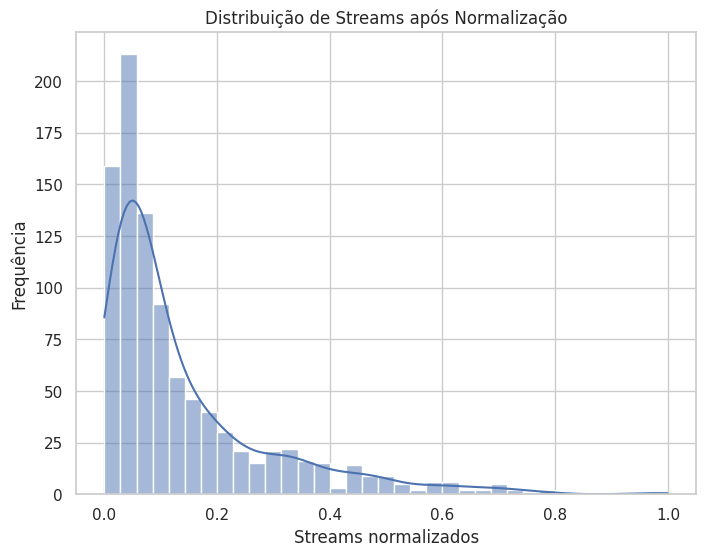

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df_normalized['streams'], kde=True)
plt.title('Distribuição de Streams após Normalização')
plt.xlabel('Streams normalizados')
plt.ylabel('Frequência')
plt.show()

A normalização reescala os atributos para uma faixa comum, facilitando comparações entre variáveis originalmente medidas em escalas muito diferentes. Essa transformação é útil para futuras aplicações em algoritmos sensíveis à magnitude dos dados.

### Padronização

In [22]:
scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X)

df_standardized = pd.DataFrame(X_standardized, columns=features)
df_standardized.head()

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,-0.657806,-0.588731,6.899341,-0.287191,4.171462,-0.340447,1.215709,6.316521,0.087708,0.891096,1.600828,1.131729,0.151729,-0.188132,-0.745256,-0.618829
1,-0.671342,-0.472052,1.839470,-0.229318,1.464149,-0.265010,1.878792,2.710631,-1.089053,0.275624,0.407730,0.587654,-0.771972,-0.188132,-0.599314,-0.618829
2,-0.660239,-0.481807,5.161607,0.303113,3.064823,-0.073516,1.878792,7.315451,0.551280,-1.092091,-0.827979,-0.681854,-0.387097,-0.188132,0.933082,-0.416966
3,0.506682,0.336718,4.497180,0.557754,3.064823,0.123781,1.547251,4.058779,1.692382,-0.818548,0.279898,0.466749,-0.618022,-0.188132,-0.526342,0.491420
4,-0.372000,-0.261878,1.941690,0.187368,1.602478,-0.096727,2.044562,3.059850,0.765237,-0.134690,-1.211475,0.950371,-0.502559,7.307062,-0.526342,-0.416966


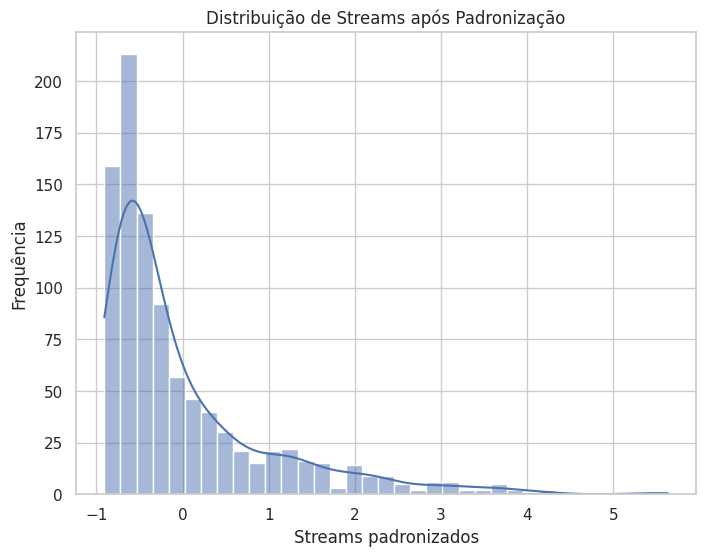

In [24]:
plt.figure(figsize=(8,6))
sns.histplot(df_standardized['streams'], kde=True)
plt.title('Distribuição de Streams após Padronização')
plt.xlabel('Streams padronizados')
plt.ylabel('Frequência')
plt.show()

A padronização ajusta os atributos para média próxima de zero e desvio padrão próximo de um. Essa etapa é especialmente relevante para preparar a base para análises futuras que dependam de escalas comparáveis entre variáveis.

## Respondendo às hipóteses

### Hipótese 1  
**Músicas com maior presença em playlists e charts tendem a apresentar maior número de streams.**

In [25]:
colunas_hipotese_1 = [col for col in ['streams', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts'] if col in df_numerico.columns]
df_numerico[colunas_hipotese_1].corr()

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts
streams,1.000000,0.789822,0.245821,0.772063,0.320234
in_spotify_playlists,0.789822,1.000000,0.164331,0.708277,0.271317
in_spotify_charts,0.245821,0.164331,1.000000,0.233354,0.552232
in_apple_playlists,0.772063,0.708277,0.233354,1.000000,0.414523
in_apple_charts,0.320234,0.271317,0.552232,0.414523,1.000000


A hipótese 1 foi sustentada pela análise. As variáveis relacionadas à presença em playlists e charts apresentaram associação positiva com o número de streams, sugerindo que a visibilidade das músicas nas plataformas está fortemente relacionada ao seu desempenho.

### Hipótese 2  
**Características musicais, como danceability, energy e valence, apresentam alguma relação com o sucesso das músicas.**

In [26]:
colunas_hipotese_2 = [col for col in ['streams', 'danceability_%', 'energy_%', 'valence_%', 'acousticness_%', 'speechiness_%'] if col in df_numerico.columns]
df_numerico[colunas_hipotese_2].corr()

,streams,danceability_%,energy_%,valence_%,acousticness_%,speechiness_%
streams,1.000000,-0.105457,-0.026051,-0.040831,-0.004485,-0.112333
danceability_%,-0.105457,1.000000,0.198095,0.408451,-0.236165,0.184977
energy_%,-0.026051,0.198095,1.000000,0.357612,-0.577344,-0.004846
valence_%,-0.040831,0.408451,0.357612,1.000000,-0.081907,0.041081
acousticness_%,-0.004485,-0.236165,-0.577344,-0.081907,1.000000,-0.022501
speechiness_%,-0.112333,0.184977,-0.004846,0.041081,-0.022501,1.000000


A hipótese 2 foi parcialmente sustentada. As características musicais analisadas demonstraram relações mais fracas com o número de streams, indicando que podem influenciar o sucesso, mas não parecem ser os fatores mais determinantes quando comparadas às variáveis de exposição.

### Hipótese 3  
**O número de streams é concentrado em poucas músicas e poucos artistas.**

In [27]:
df[['track_name', 'artist(s)_name', 'streams']].sort_values('streams', ascending=False).head(20)

,track_name,artist(s)_name,streams
55,Blinding Lights,The Weeknd,3.703895e+09
179,Shape of You,Ed Sheeran,3.562544e+09
86,Someone You Loved,Lewis Capaldi,2.887242e+09
620,Dance Monkey,Tones and I,2.864792e+09
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.808097e+09
162,One Dance,"Drake, WizKid, Kyla",2.713922e+09
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.665344e+09
140,Believer,Imagine Dragons,2.594040e+09
725,Closer,"The Chainsmokers, Halsey",2.591224e+09
48,Starboy,"The Weeknd, Daft Punk",2.565530e+09


A hipótese 3 foi confirmada. Tanto a distribuição de streams quanto os rankings de músicas e artistas mostram forte concentração de sucesso, evidenciando que uma parcela reduzida das faixas concentra grande parte da audiência.

### Hipótese 4  
**O ano de lançamento pode influenciar o desempenho das músicas em streams.**

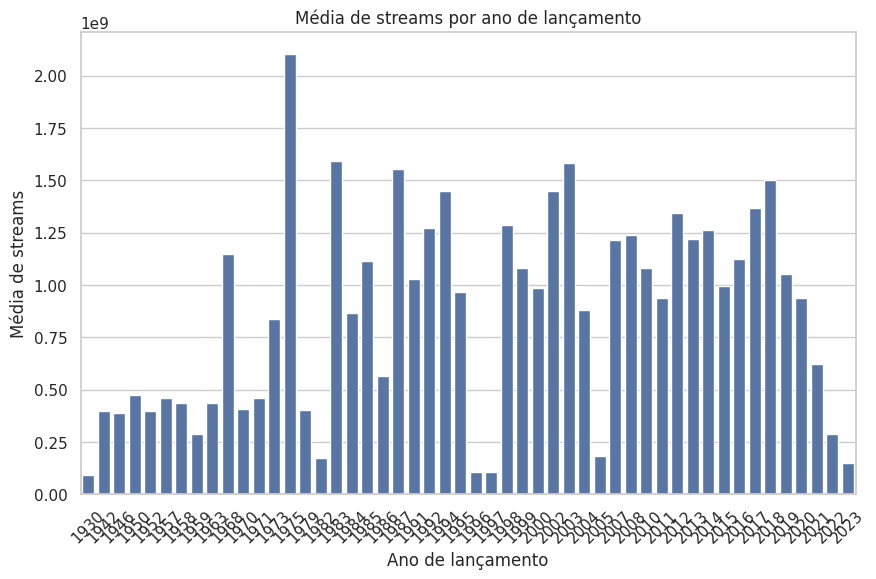

In [28]:
media_streams_ano = df.groupby('released_year', as_index=False)['streams'].mean()

plt.figure(figsize=(10,6))
sns.barplot(data=media_streams_ano, x='released_year', y='streams')
plt.title('Média de streams por ano de lançamento')
plt.xlabel('Ano de lançamento')
plt.ylabel('Média de streams')
plt.xticks(rotation=45)
plt.show()

A hipótese 4 pode ser observada de forma exploratória pela média de streams por ano de lançamento. Caso músicas mais recentes apresentem maior média, isso sugere efeito de recência; caso contrário, pode haver permanência relevante de músicas lançadas em anos anteriores.

## Conclusão

A análise exploratória do dataset **Most Streamed Spotify Songs 2023** permitiu identificar padrões importantes sobre o desempenho das músicas no Spotify.

Os resultados mostraram  concentração do número de streams em poucas faixas e alguma análise exploratória do dataset Most Streamed Spotify Songs 2023 permitiu identificar alguns padrões relevantes sobre o desempenho das músicas na plataforma.

Um dos pontos que se demosntraram mais claros foi um forte concentração de streams em poucas faixas e artistas, o que está alinhado com o comportamento típico de consumo em plataformas digitais.

Também foi possível observar que variáveis relacionadas à visibilidade, como presença em playlists e charts, apresentam uma associação mais clara com o número de reproduções.

Já as características musicais, como danceability, energy e valence, mostraram uma relação mais discreta. Isso indica que, embora o perfil sonoro tenha sua importância, fatores ligados à exposição parecem ter maior peso no alcance das músicas.

Ao longo do trabalho, foram realizadas etapas de tratamento e preparação dos dados, como conversão de tipos, análise de valores ausentes, imputação por mediana e aplicação de normalização e padronização. Essas etapas contribuíram para melhorar a qualidade da base e tornar a análise mais consistente.

De forma geral, o projeto reforça a importância da análise exploratória e do pré-processamento como etapas iniciais para entender melhor os dados, validar hipóteses e extrair insights que podem apoiar análises mais avançadas no futuro.